#support vector regressor

#🔧 Step 1: Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVR
from sklearn.datasets import make_regression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score


#📊 Step 2: Generate Synthetic Regression Data

In [2]:
# Generate data: 1 feature, some noise
X, y = make_regression(n_samples=100, n_features=1, noise=20, random_state=42)

# Reshape y to be a 1D array
y = y.reshape(-1)


#🔍 Step 3: Feature Scaling

SVR is sensitive to the scale of features, so we scale X and y.

In [3]:
# Scale both X and y
x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_scaled = x_scaler.fit_transform(X)
y_scaled = y_scaler.fit_transform(y.reshape(-1, 1)).flatten()


#📚 Step 4: Split into Train & Test

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.2, random_state=42)


#⚙️ Step 5: Train SVR Model (RBF Kernel)

In [5]:
# Create and train SVR model with RBF kernel
svr_model = SVR(kernel='rbf', C=10, epsilon=0.1)
svr_model.fit(X_train, y_train)


SVR(C=10)

#🔮 Step 6: Make Predictions

In [6]:
# Predict on test data
y_pred_scaled = svr_model.predict(X_test)

# Inverse transform predictions to original scale
y_pred = y_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
y_test_original = y_scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()


#📈 Step 7: Visualize Results

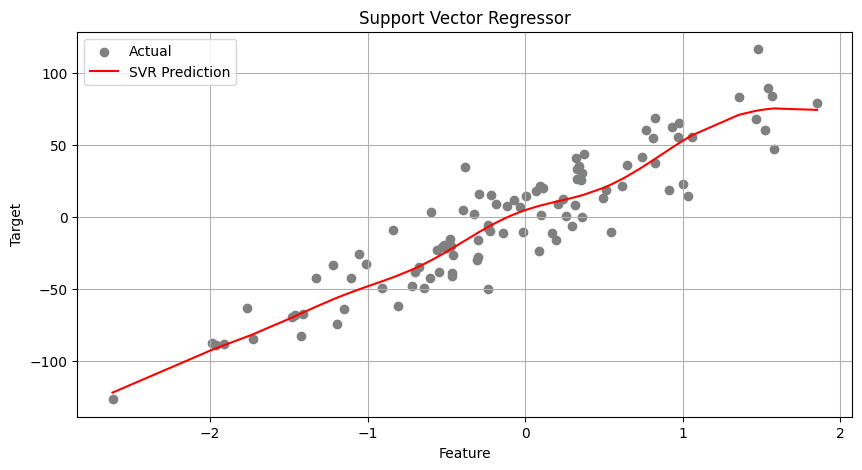

In [7]:
# Predict on the whole dataset for smoother plot
X_all_sorted = np.sort(X, axis=0)
y_pred_all = svr_model.predict(x_scaler.transform(X_all_sorted))
y_pred_all_inv = y_scaler.inverse_transform(y_pred_all.reshape(-1, 1)).flatten()

# Plot original vs prediction
plt.figure(figsize=(10, 5))
plt.scatter(X, y, color='gray', label='Actual')
plt.plot(X_all_sorted, y_pred_all_inv, color='red', label='SVR Prediction')
plt.title('Support Vector Regressor')
plt.xlabel('Feature')
plt.ylabel('Target')
plt.legend()
plt.grid(True)
plt.show()


#📊 Step 8: Evaluate Model

In [8]:
mse = mean_squared_error(y_test_original, y_pred)
r2 = r2_score(y_test_original, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R² Score: {r2:.2f}")


Mean Squared Error: 403.76
R² Score: 0.81


# Recap: Key Hyperparameters

| Parameter | Description                                                  |
| --------- | ------------------------------------------------------------ |
| `kernel`  | `'linear'`, `'poly'`, `'rbf'`, `'sigmoid'`                   |
| `C`       | Regularization (higher = less margin, overfitting risk)      |
| `epsilon` | Margin of tolerance (only errors outside this are penalized) |
| `gamma`   | Controls kernel influence (for RBF/poly)                     |


#✅ When to Use SVR

Works well with small to medium datasets

Great for non-linear regression when using kernels

Must scale features before training